In [1]:
import matplotlib.pyplot as plt
from scipy import signal
import numpy as np
from adsp import adspfilter
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)
def set_dark_style():
    plt.style.use("default")
    plt.rcParams.update({
        "figure.facecolor": "#000000",
        "axes.facecolor":   "#000000",
        "axes.edgecolor":   "#FFFFFF",
        "axes.labelcolor":  "#FFFFFF",
        "text.color":       "#FFFFFF",
        "xtick.color":      "#FFFFFF",
        "ytick.color":      "#FFFFFF",
        "grid.color":       "#444444",
        "legend.facecolor": "#000000",
        "legend.edgecolor": "#FFFFFF",
        "savefig.facecolor":"#000000",
        "savefig.edgecolor":"#000000",
    })
set_dark_style()

Diniz Example 3.6 / Section 6.9.2: AP, SM-AP, SM-PUAP
Number of coefficients: 8
Filter order: 7
Noise variance sigma_n^2: 0.0001

Running eigenvalue spread case: 1.0
  Trial 1/100
  Trial 10/100
  Trial 20/100
  Trial 30/100
  Trial 40/100
  Trial 50/100
  Trial 60/100
  Trial 70/100
  Trial 80/100
  Trial 90/100
  Trial 100/100

Average update rates:
  AP L=0                  : N/A
  AP L=1                  : N/A
  AP L=4                  : N/A
  SM-AP L=0               : 0.0556 (5.56%)
  SM-AP L=1               : 0.0554 (5.54%)
  SM-AP L=4               : 0.0665 (6.65%)

Running eigenvalue spread case: 20.0
  Trial 1/100
  Trial 10/100
  Trial 20/100
  Trial 30/100
  Trial 40/100
  Trial 50/100
  Trial 60/100
  Trial 70/100
  Trial 80/100
  Trial 90/100
  Trial 100/100

Average update rates:
  AP L=0                  : N/A
  AP L=1                  : N/A
  AP L=4                  : N/A
  SM-AP L=0               : 0.0641 (6.41%)
  SM-AP L=1               : 0.0617 (6.17%)
  SM-AP L=4  

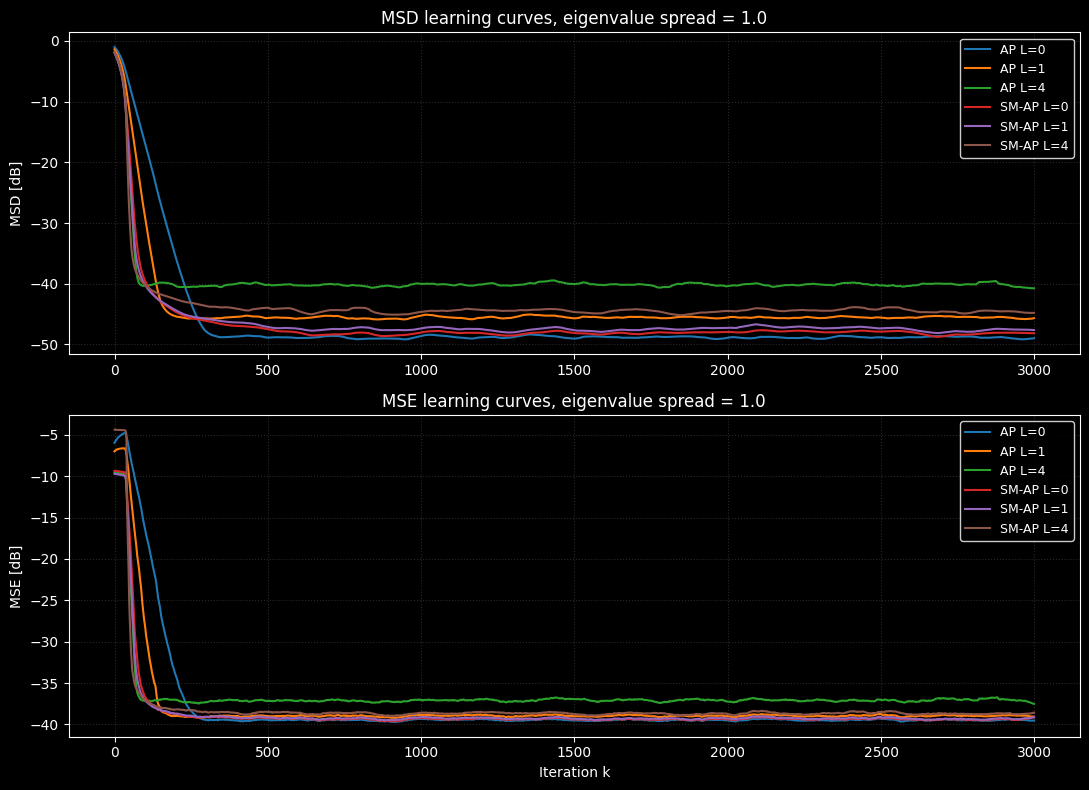

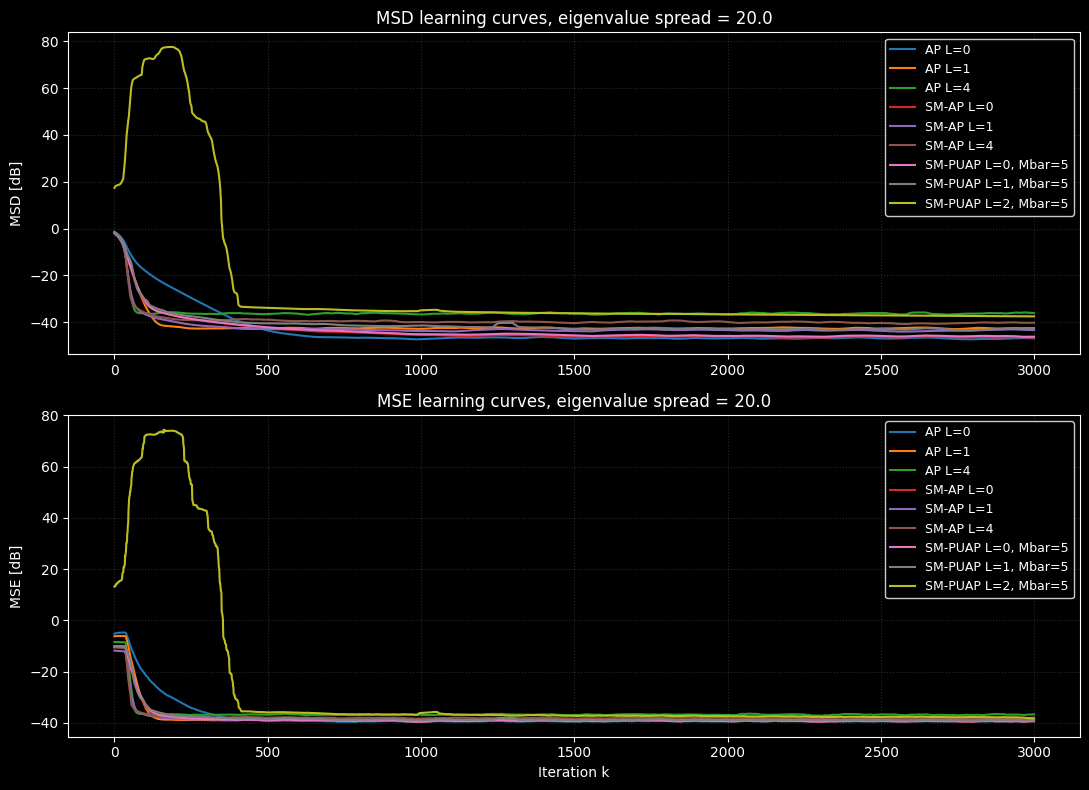

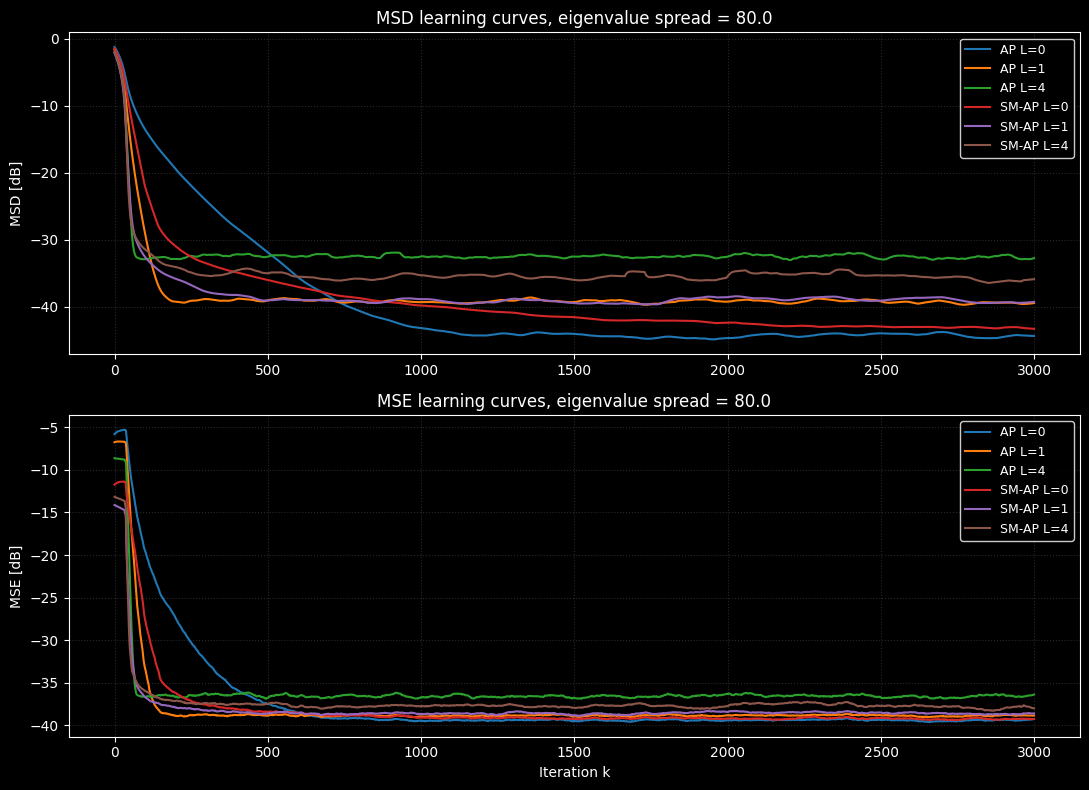

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import math

def generateDinizInput(length: int, spread_case: float, var_x: float = 1.0, burn_in: int = 512) -> np.ndarray:
  """
  Generate AR(1) colored input for Diniz Example 3.6.

  For filter length M = 8:
    eigenvalue spread = 1   -> rho = 0.0
    eigenvalue spread = 20  -> rho = 0.689399
    eigenvalue spread = 80  -> rho = 0.870189
  """
  if math.isclose(spread_case, 1.0):
    rho = 0.0
  elif math.isclose(spread_case, 20.0):
    rho = 0.689399
  elif math.isclose(spread_case, 80.0):
    rho = 0.870189
  else:
    raise ValueError("Only eigenvalue spreads 1, 20, and 80 are supported.")

  total_len = length + burn_in

  var_v = var_x * (1.0 - rho ** 2)
  v = np.random.normal(0.0, math.sqrt(var_v), total_len)

  x = np.zeros(total_len, dtype=np.float64)

  for k in range(1, total_len):
    x[k] = rho * x[k - 1] + v[k]

  x = x[burn_in:]

  # Normalize to unit variance.
  x = x / max(np.std(x), 1e-12)

  return x.astype(np.complex64)


def makeDesiredSignal(x_signal, h, noise_var):
  """
  Generate desired signal:

    d(k) = h^H x(k) + n(k)
  """
  num_iterations = len(x_signal)
  n_coef = len(h)

  d_clean = np.zeros(num_iterations, dtype=np.complex64)

  for k in range(num_iterations):
    reg = x_signal[max(0, k - n_coef + 1):k + 1][::-1]

    if len(reg) < n_coef:
      reg = np.pad(reg, (0, n_coef - len(reg)))

    d_clean[k] = np.vdot(h, reg)

  noise = np.random.normal(
    0.0,
    math.sqrt(noise_var),
    num_iterations,
  ).astype(np.complex64)

  return d_clean + noise


def smoothCurve(x, win_len=64):
  x = np.asarray(x, dtype=np.float64)

  if win_len <= 1:
    return x

  pad_left = win_len // 2
  pad_right = win_len - 1 - pad_left

  x_pad = np.pad(x, (pad_left, pad_right), mode="edge")
  win = np.ones(win_len, dtype=np.float64) / float(win_len)

  return np.convolve(x_pad, win, mode="valid")


def getPuapGammaBar(L, sigma_n):
  """
  SM-PUAP gamma-bar values used in Example 6.2 style:

    L = 0 -> sqrt(5)  sigma_n
    L = 1 -> sqrt(7)  sigma_n
    L = 2 -> sqrt(17) sigma_n
  """
  if L == 0:
    return math.sqrt(5.0) * sigma_n

  if L == 1:
    return math.sqrt(7.0) * sigma_n

  if L == 2:
    return math.sqrt(17.0) * sigma_n

  raise ValueError(f"No PUAP gamma rule for L={L}.")


def makeModels(filter_order, sigma_n, spread_case):
  """
  Build AP, SM-AP, and faithful Diniz-style SM-PUAP models.

  Textbook mapping:
    L in Diniz textbook == P in this code.

  Section 6.9.2:
    AP:      L = 0, 1, 4
    SM-AP:   L = 0, 1, 4
    SM-PUAP: L = 0, 1, 2, Mbar = 5, only for eigenvalue spread 20
  """
  models = {}

  # Ordinary affine projection: L = 0, 1, 4
  for L in [0, 1, 4]:
    models[f"AP L={L}"] = adspfilter.AffineProjection(
      filter_order=filter_order,
      mu=0.18,
      P=L,
      delta=1e-6,
    )

  # Simplified SM-AP: L = 0, 1, 4
  gamma_bar_smap = math.sqrt(5.0) * sigma_n

  for L in [0, 1, 4]:
    models[f"SM-AP L={L}"] = adspfilter.SMAffineProjection(
      filter_order=filter_order,
      gamma_bar=gamma_bar_smap,
      P=L,
      delta=1e-6,
    )

  # Faithful Diniz-style SM-PUAP only for eigenvalue spread 20
  if math.isclose(spread_case, 20.0):
    for L in [0, 1, 2]:
      models[f"SM-PUAP L={L}, Mbar=5"] = adspfilter.SMPartialUpdateAffineProjection(
        filter_order=filter_order,
        gamma_bar=getPuapGammaBar(L, sigma_n),
        P=L,
        max_update=5,
        delta=1e-3,
        selector_mode="topEnergy",
      )

  return models


def runExample36ApSmapPuapSimulation():
  # -------------------------------------------------------------------------
  # 1. Diniz Example 3.6 parameters
  # -------------------------------------------------------------------------
  num_iterations = 3000
  num_trials = 100

  h = np.array(
    [0.1, 0.3, 0.0, -0.2, -0.4, -0.7, -0.4, -0.2],
    dtype=np.complex64,
  )

  n_coef = len(h)
  filter_order = n_coef - 1

  sigma_x2 = 1.0
  sigma_n2 = 1e-4
  sigma_n = math.sqrt(sigma_n2)

  spread_cases = [1.0, 20.0, 80.0]

  results = {}

  print("=" * 72)
  print("Diniz Example 3.6 / Section 6.9.2: AP, SM-AP, SM-PUAP")
  print("=" * 72)
  print(f"Number of coefficients: {n_coef}")
  print(f"Filter order: {filter_order}")
  print(f"Noise variance sigma_n^2: {sigma_n2}")
  print("=" * 72)

  # -------------------------------------------------------------------------
  # 2. Monte Carlo simulation
  # -------------------------------------------------------------------------
  for spread in spread_cases:
    print(f"\nRunning eigenvalue spread case: {spread}")

    # Get model names once for this spread.
    tmp_models = makeModels(
      filter_order=filter_order,
      sigma_n=sigma_n,
      spread_case=spread,
    )

    algo_names = list(tmp_models.keys())

    msd_curves = {
      name: np.zeros(num_iterations, dtype=np.float64)
      for name in algo_names
    }

    mse_curves = {
      name: np.zeros(num_iterations, dtype=np.float64)
      for name in algo_names
    }

    update_rates = {
      name: []
      for name in algo_names
    }

    for trial in range(num_trials):
      if trial == 0 or (trial + 1) % 10 == 0:
        print(f"  Trial {trial + 1}/{num_trials}")

      x_signal = generateDinizInput(
        length=num_iterations,
        spread_case=spread,
        var_x=sigma_x2,
      )

      d_signal = makeDesiredSignal(
        x_signal=x_signal,
        h=h,
        noise_var=sigma_n2,
      )

      models = makeModels(
        filter_order=filter_order,
        sigma_n=sigma_n,
        spread_case=spread,
      )

      for name, model in models.items():
        y_h, e_h, w_h = model(x_signal, d_signal, train=True)

        # AP/SM-AP/SM-PUAP with P > 0 starts later.
        offset = num_iterations - len(e_h)

        # Fill initial samples before algorithm output starts.
        initial_msd = float(np.sum(np.abs(h) ** 2))

        for k in range(offset):
          msd_curves[name][k] += initial_msd
          mse_curves[name][k] += float(np.abs(d_signal[k]) ** 2)

        for idx in range(len(e_h)):
          k = idx + offset

          # Use post-update weight vector.
          w_idx = min(idx + 1, w_h.shape[0] - 1)
          w_current = w_h[w_idx]

          msd = np.sum(np.abs(h - w_current) ** 2)
          mse = np.abs(e_h[idx]) ** 2

          if np.isfinite(msd):
            msd_curves[name][k] += float(msd)

          if np.isfinite(mse):
            mse_curves[name][k] += float(mse)

        if hasattr(model, "getUpdateRate"):
          update_rates[name].append(model.getUpdateRate())

    # Average over Monte Carlo trials.
    for name in algo_names:
      msd_curves[name] /= num_trials
      mse_curves[name] /= num_trials

    results[spread] = {
      "msd": msd_curves,
      "mse": mse_curves,
      "update_rates": update_rates,
    }

    # Print update rates.
    print("\nAverage update rates:")
    for name in algo_names:
      rates = update_rates[name]

      if len(rates) == 0:
        print(f"  {name:<24s}: N/A")
      else:
        p_up = float(np.mean(rates))
        print(f"  {name:<24s}: {p_up:.4f} ({100.0 * p_up:.2f}%)")

  # -------------------------------------------------------------------------
  # 3. Plot one figure per eigenvalue spread
  # -------------------------------------------------------------------------
  for spread in spread_cases:
    plotSpreadResult(results, spread)

  return results


def plotSpreadResult(results, spread):
  msd_curves = results[spread]["msd"]
  mse_curves = results[spread]["mse"]

  fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8))

  for name in msd_curves:
    ax1.plot(
      10.0 * np.log10(smoothCurve(msd_curves[name], 64) + 1e-12),
      label=name,
      linewidth=1.5,
    )

    ax2.plot(
      10.0 * np.log10(smoothCurve(mse_curves[name], 64) + 1e-12),
      label=name,
      linewidth=1.5,
    )

  ax1.set_title(f"MSD learning curves, eigenvalue spread = {spread}")
  ax1.set_ylabel("MSD [dB]")
  ax1.grid(True, linestyle=":", alpha=0.6)
  ax1.legend(fontsize=9)

  ax2.set_title(f"MSE learning curves, eigenvalue spread = {spread}")
  ax2.set_xlabel("Iteration k")
  ax2.set_ylabel("MSE [dB]")
  ax2.grid(True, linestyle=":", alpha=0.6)
  ax2.legend(fontsize=9)

  plt.tight_layout()
  plt.show()


if __name__ == "__main__":
  results = runExample36ApSmapPuapSimulation()